# Activity: Singular Value Decomposition (SVD) of the Stoichiomatric Matrix for Genome-Scale Metabolic Models
In this activity, we will perform Singular Value Decomposition (SVD) on the stoichiometric matrix of a genome-scale metabolic model (GEM) and analyze the results to gain insights into the metabolic capabilities of the organism. Thus, we continue our analysis from the previous module of the covariance matrix computed from the stiochiometric matrix.

> __Learning Objectives:__
> 
> By the end of this activity, you will be able to:
>
> Three learning objectives here.

Let's get started!
___

## Background: What is a stoichiometric matrix?
Suppose we have a set of chemical (or biochemical) reactions $\mathcal{R}$ involving the chemical species (metabolite) set $\mathcal{M}$. Then, the stoichiometric matrix is a $\mathbf{S}\in\mathbb{R}^{|\mathcal{M}|\times|\mathcal{R}|}$ matrix that holds the stoichiometric coefficients $\sigma_{ij}\in\mathbf{S}$ such that:
* $\sigma_{ij}>0$: Chemical species (metabolite) $i$ is _produced_ by reaction $j$. Species $i$ is a product of reaction $j$.
* $\sigma_{ij} = 0$: Chemical species (metabolite) $i$ is not connected with reaction $j$
* $\sigma_{ij}<0$: Chemical species (metabolite) $i$ is _consumed_ by reaction $j$. Species $i$ is a reactant of reaction $j$.

Thus, the stoichiometric matrix $\mathbf{S}$ encodes the complete connectivity information of the chemical reaction system for, in this case, a biochemical reaction network. Thus, it is the digital representation of the reaction network inside of a cell.
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We developed a simple software development kit (SDK) against [the BiGG Models application programming interface at the University of California, San Diego](http://bigg.ucsd.edu/). The [BiGG Models database](http://bigg.ucsd.edu/) integrates published genome-scale metabolic networks into a single database with standardized nomenclature and structure. 

> __What are we doing here?__
> 
> We are going to download a stoichiometric matrix from [the BiGG models database](http://bigg.ucsd.edu/) using [the BiGG models API](http://bigg.ucsd.edu/data_access) and then compute its eigendecomposition. 
> * [The BiGG models API](http://bigg.ucsd.edu/data_access) allows users to programmatically access genome-scale stoichiometric model reconstructions using a simple web API. There are `108` models of intracellular biochemistry occurring in various organisms (including humans) in the database (so far); [see here for a list of models](http://bigg.ucsd.edu/models).
> * Here, we'll first explore the [model of Platelet metabolism developed by Palsson and coworkers](https://pubmed.ncbi.nlm.nih.gov/24473230/), which is a curated, functionally tested, and experimentally validated biochemical reaction network of Human platelet metabolism. This model has 738 metabolites and 1008 reactions. 
> 
>  We call the model download endpoint of [the BiGG models API](http://bigg.ucsd.edu/data_access) and then save the model file to disk (so we don't hit the API unless we have to). 

This call returns model information organized as [a Julia dictionary](https://docs.julialang.org/en/v1/base/collections/#Base.Dict) in the `model::Dict{String, Any}` variable. If a model file is saved, we use the cached file instead of making an API call.

In [2]:
model = let

    # build download endpoint -
    baseurl = "http://bigg.ucsd.edu"; # base url to download model
    modelid = "e_coli_core"; # model id to download (change as needed) (e.g., iAB_RBC_283, e_coli_core, iAT_PLT_636, etc.)
    path_to_saved_model_file = joinpath(_PATH_TO_DATA, "saved-model-$(modelid).jld2");

    # check: do we have a model file saved?
    model = nothing;
    if (isfile(path_to_saved_model_file) == false)
        
        endpoint = MyBiggModelsDownloadModelEndpointModel();
        endpoint.bigg_id = modelid;
        url = build(baseurl, endpoint)
        model = MyBiggModelsDownloadModelEndpointModel(url);

        # Before we move on, save this model for later (so we don't keep hitting the API)
        save(path_to_saved_model_file, Dict("model" => model));
    else
        model = load(path_to_saved_model_file)["model"];
    end
    model; # return the model (either saved, or downloaded)
end

JSON.Object{String, Any} with 6 entries:
  "metabolites"  => Any[Object{String, Any}("id"=>"glc__D_e", "name"=>"D-Glucos…
  "reactions"    => Any[Object{String, Any}("id"=>"PFK", "name"=>"Phosphofructo…
  "genes"        => Any[Object{String, Any}("id"=>"b1241", "name"=>"adhE", "not…
  "id"           => "e_coli_core"
  "compartments" => Object{String, Any}("c"=>"cytosol", "e"=>"extracellular spa…
  "version"      => "1"

__Metabolite records__: Each metabolite (chemical compound) in the network has an associated metabolite record with several fields. Let's take a look at the metabolite at index `1`. The key field for today in the metabolite record is the `id` field, an abbreviation or symbol associated with this metabolite.

In [3]:
model["metabolites"][2] # example metabolite record

JSON.Object{String, Any} with 7 entries:
  "id"          => "gln__L_c"
  "name"        => "L-Glutamine"
  "compartment" => "c"
  "charge"      => 0
  "formula"     => "C5H10N2O3"
  "notes"       => Object{String, Any}("original_bigg_ids"=>Any["gln_L_c"])
  "annotation"  => Object{String, Any}("bigg.metabolite"=>Any["gln__L"], "biocy…

__Reaction records__: Similarly, each reaction in the network has a reaction record with several fields. Let's look at the reaction record at index `25`. The key field for the reaction record is the `metabolites` field, which lists the stoichiometric coefficients associated with this particular reaction.

In [4]:
model["reactions"][25] # example reaction record

JSON.Object{String, Any} with 10 entries:
  "id"                    => "BIOMASS_Ecoli_core_w_GAM"
  "name"                  => "Biomass Objective Function with GAM"
  "metabolites"           => Object{String, Any}("3pg_c"=>-1.496, "accoa_c"=>-3…
  "lower_bound"           => 0.0
  "upper_bound"           => 1000.0
  "gene_reaction_rule"    => ""
  "objective_coefficient" => 1.0
  "subsystem"             => "Biomass and maintenance functions"
  "notes"                 => Object{String, Any}("original_bigg_ids"=>Any["Biom…
  "annotation"            => Object{String, Any}("bigg.reaction"=>Any["BIOMASS_…

For each reaction record, we can see the chemical species (metabolites) involved in the reaction and their associated stoichiometric coefficients. Negative coefficients indicate reactants (consumed), while positive coefficients indicate products (produced).

In [5]:
model["reactions"][25]["metabolites"]

JSON.Object{String, Any} with 23 entries:
  "3pg_c"    => -1.496
  "accoa_c"  => -3.7478
  "adp_c"    => 59.81
  "akg_c"    => 4.1182
  "atp_c"    => -59.81
  "coa_c"    => 3.7478
  "e4p_c"    => -0.361
  "f6p_c"    => -0.0709
  "g3p_c"    => -0.129
  "g6p_c"    => -0.205
  "gln__L_c" => -0.2557
  "glu__L_c" => -4.9414
  "h2o_c"    => -59.81
  "h_c"      => 59.81
  "nad_c"    => -3.547
  "nadh_c"   => 3.547
  "nadp_c"   => 13.0279
  "nadph_c"  => -13.0279
  "oaa_c"    => -1.7867
  ⋮          => ⋮

__Stoichiometric matrix__: Next, let's build a stoichiometric matrix $\mathbf{S}$ using the metabolite and reaction records. We'll do this using two for loops. 

> __Strategy__: In the outer loop, we iterate over the system's metabolites (chemical species) and select the `id` from the metabolites record for each metabolite. In the inner loop, we iterate over each reaction. For each reaction record, we ask if this reaction has an entry for the current metabolite `id` value; if it does, we grab the stoichiometric coefficient $\sigma_{ij}$ corresponding to this metabolite and reaction.

We'll save the stoichiometric matrix in the `S::Matrix{Float64}` variable.

In [6]:
S = let

    # get some data from the model -
    m = model["metabolites"]; # get list of metabolites
    r = model["reactions"]; # get list of reactions
    number_of_rows = length(m); # how many metabolites do we have? (rows)
    number_of_cols = length(r); # how many reactions do we have? (cols)
    S = zeros(number_of_rows,number_of_cols); # initialize an empty stoichiometric matrix

    # let's build a stm -
    for i ∈ eachindex(m)
        metabolite = m[i]["id"]; # we are checking if this metabolite is in the reaction record
        for j ∈ eachindex(r)
            reaction = r[j];
            if (haskey(reaction["metabolites"], metabolite) == true)
                S[i,j] = reaction["metabolites"][metabolite];
            end
        end
    end
    S; 
end;

___

## Task 1: Perform Singular Value Decomposition (SVD) on the Stoichiometric Matrix
In this task, we will perform Singular Value Decomposition (SVD) on the stoichiometric matrix $\mathbf{S}$ to analyze its properties and gain insights into the metabolic capabilities of our example metabolic model. We'll use [the built-in `svd(...)` function from Julia's `LinearAlgebra` standard library](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) to compute the SVD of the stoichiometric matrix $\mathbf{S}$, where we'll use QR iteration as the algorithm for computing the SVD.

The SVD decomposes the matrix into three components: $\mathbf{U}$, $\mathbf{\Sigma}$, and $\mathbf{V}^{\top}$, where:
$$
\begin{align*}
\mathbf{S} &= \mathbf{U} \mathbf{\Sigma} \mathbf{V}^{\top} \\
\end{align*}
$$
where $\mathbf{U}$ is the left singular vectors matrix, $\mathbf{\Sigma}$ is the diagonal matrix of singular values, and $\mathbf{V}^{\top}$ is the transpose of the right singular vectors matrix. We'll store the results in the variables `U::Array{Float64,2}`, `Σ::Array{Float64,1}`, and `V::Array{Float64,2}` arrays.

In [7]:
U, Σ, V = svd(S, alg = LinearAlgebra.QRIteration(), full = true); # perform SVD on the stoichiometric matrix S. The full = true argument ensures that we get the full-sized U and V matrices.

What is contained in the `U`, `Σ`, and `V` matrices? How can we interpret these results in the context of the metabolic model? Let's start by looking at the dimensions of these matrices.

The `U::Array{Float64,2}` matrix has dimensions $|\mathcal{M}| \times |\mathcal{M}|$, where $|\mathcal{M}|$ is the number of metabolites (chemical compounds) in the model. Each column of `U::Array{Float64,2}` represents a left singular vector, which can be interpreted as a basis vector in the __metabolite space__. 

In [8]:
U

72×72 Matrix{Float64}:
  1.02698e-6   -2.80482e-5    0.000496469  …   1.47381e-17  -1.53346e-17
 -0.00166848    0.0109184    -0.0201739        3.09238e-16  -7.94658e-17
 -0.000120082  -0.000320469   0.0045505        1.99718e-16  -1.05347e-16
 -0.0365352    -0.00241599    0.0617328        1.4342e-16    4.86025e-17
 -2.21565e-5   -0.0122306    -0.000127965      1.87934e-17  -1.20875e-16
 -5.11327e-5   -0.00485667    0.0282984    …   6.91954e-17  -5.32485e-17
 -0.441514      0.117706      0.170176        -8.81686e-17   3.01508e-18
  2.40228e-5   -0.00108909   -0.0064007       -5.31869e-17  -1.55744e-16
  0.442801      0.647595      0.0494662        5.27782e-17   3.70255e-17
 -0.000947949  -0.676667      0.107797         4.54676e-17   5.93529e-17
  ⋮                                        ⋱   ⋮            
 -0.000547438  -0.00530773   -0.0186932        2.68801e-16   5.23218e-17
  2.42128e-5    0.00553391    0.0173345        4.67753e-16   3.18065e-17
  2.22852e-5    0.0124873     0.0167403 

What about the $\mathbf{V}$ matrix? The `V::Array{Float64,2}` matrix has dimensions $|\mathcal{R}| \times |\mathcal{M}|$, where $|\mathcal{R}|$ is the number of reactions in the model, and $|\mathcal{M}|$ is the number of metabolites. Each column of `V::Array{Float64,2}` represents a right singular vector, which can be interpreted as a basis vector in the __reaction space__.

Why isn't the `V::Array{Float64,2}` matrix $|\mathcal{R}| \times |\mathcal{R}|$ in size? This is the difference between the _full_ and _thin_ singular value decomposition. Here, we are using the thin SVD, which is more computationally efficient for large matrices like stoichiometric matrices in genome-scale metabolic models.

In [9]:
V

95×95 adjoint(::Matrix{Float64}) with eltype Float64:
  0.00978312    0.0294866     0.0296719    …   0.0192839    0.0384167
 -0.00025239    1.24597e-5    0.0945162        0.0361779   -0.215308
  7.21032e-6    0.000155411  -0.00583137      -0.0886119    0.0299086
  0.00659487   -0.0333661     0.02417         -0.0777788    0.00618186
  0.00652332    0.0505945    -0.0205478        0.0242769   -0.059358
  0.00324662    0.0714136     0.317973     …   0.0587187   -0.0679802
  0.00349759    0.129239     -0.0359363        0.0447871    0.143865
 -8.18331e-5    0.000700125   0.000595877     -0.0792261   -0.00065667
  0.00652871    0.112275     -0.0216546       -0.00355905  -0.0168161
  0.00365431    0.0705532     0.22741          0.0305122   -0.0115549
  ⋮                                        ⋱               
  0.00654726    0.256643     -0.051317         0.132762     0.0253748
  0.00355638    0.070387      0.259566         0.00723093   0.0160638
  0.000231958   0.00899959    0.276724         

How about the $\mathbf{\Sigma}$ matrix? The singular values returned by [the `svd(...)` functio](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) are in a vector form (sorted from largest to smallest), in particular a $|\mathcal{M}|$-dimensional vector. We can work with this vector directly (as we do below), but often it can be useful to also have the singular values in matrix form.

In [10]:
Σ

72-element Vector{Float64}:
 135.57637933587276
  10.49176085014799
   5.346688719867401
   4.808046290162294
   4.476164115390653
   3.8663667015578653
   3.7485661165415536
   3.5394515762626275
   3.3778492002340927
   3.0501839354928006
   ⋮
   0.4475724591426078
   0.39338287149367096
   0.34035590268750965
   0.11611268983819607
   8.760449518173397e-16
   6.836587858100821e-16
   5.577268241689454e-16
   3.698577031114704e-16
   3.209883527009791e-16

One of the cool things about [singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) is that modes (the rank one components) are sorted and weighted by the singular values. Thus, we can compute the contribution of each mode by looking at the singular values.

Let's compute and visualize how much information, i.e., what fraction of the original matrix, is explained by each mode by looking at the cumulative sum.

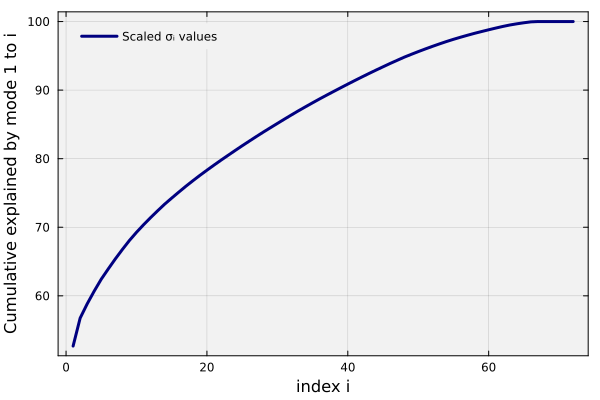

In [ ]:
let
    
    # make a plot of the fractional contribution of the singular values
    number_of_modes = length(Σ);
    SS = (1/sum(Σ))*Σ;
    explained_array = [100*sum(SS[1:i]) for i ∈ 1:number_of_modes]; # comprehension

    plot(explained_array, label="Scaled σᵢ values", lw=3, c=:navy)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    xlabel!("mode index i", fontsize=18)
    ylabel!("Cumulative explained by mode 1 to i", fontsize=18)
end

__What do we see?__ Fill me in here.

To convert the $\mathbf{\Sigma}$ vector into a diagonal matrix, we can use [the `diagm(...)` function from Julia's standard library](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.diagm). The diagonal entries of the $\mathbf{\Sigma}$ matrix represent the singular values, which provide insights into the rank and condition number of the stoichiometric matrix $\mathbf{S}$. 

> __Rank and Condition Number:__
>
> * __Rank__: The number of non-zero singular values indicates the rank of the matrix, $r(\mathbf{S})\leq \min(|\mathcal{M}|, |\mathcal{R}|)$. A matrix with full rank (i.e., rank equal to the smaller of the number of rows or columns) indicates that the reactions in the metabolic model are linearly independent, meaning that each reaction contributes unique information to the system. On the other hand, a rank-deficient matrix (i.e., rank less than the smaller of the number of rows or columns) indicates that some reactions can be expressed as linear combinations of other reactions. 
> * __Condition Number__: The condition number of the stoichiometric matrix $\mathbf{S}$ can be computed as the ratio of the largest singular value to the smallest non-zero singular value. A high condition number indicates that the matrix is ill-conditioned, which can lead to numerical instability in computations involving the matrix, such as solving linear systems or performing optimization.

Let's check out these connections, by first computing the rank of the stoichiometric matrix $\mathbf{S}$ using [the `rank(...)` function from Julia's `LinearAlgebra` standard library](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank) and then counting the number of non-zero singular values in the `Σ::Array{Float64,1}` array.

In [11]:
let

    # initialize -
    ϵ = 1e-10; # threshold for considering singular values as non-zero
    r = rank(S); # compute the rank of the stoichiometric matrix S
    (M,R) = size(S); # get dimensions of S

    # how many non-zero singular values do we have?
    num_nonzero_singular_values = sum(σ -> σ > ϵ, Σ); # wow! that is some fancy functional programming there!

    # print results -
    println("Rank of the stoichiometric matrix S: $r");
    println("Number of non-zero singular values: $num_nonzero_singular_values");

    # Is the stoichiometric matrix S rank-deficient or full rank?
    if r < min(M,R)
        println("The stoichiometric matrix S is rank-deficient.");
    else
        println("The stoichiometric matrix S has full rank.");
    end
end

Rank of the stoichiometric matrix S: 67
Number of non-zero singular values: 67
The stoichiometric matrix S is rank-deficient.


What does it mean that the stoichiometric matrix $\mathbf{S}$ is rank-deficient? This suggest that some rows or columns of the matrix can be expressed as linear combinations of other rows or columns. In the context of metabolic networks, this implies that some reactions are not independent and can be derived from others. 

Next, if this matrix is rank deficient, we expect the condition number to be large. Let's compute the condition number of the stoichiometric matrix $\mathbf{S}$ using the singular values in the `Σ::Array{Float64,1}` array.

In [12]:
let

    # initialize
    ϵ = 1e-10; # threshold for considering singular values as non-zero
    σ₁ = Σ[1]; # largest singular value
    σ₂ = findall(σ -> σ > ϵ, Σ) |> i-> Σ[i[end]]; # findall indices of non-zero singular values, get the last index, and use that to get the smallest non-zero singular value
   
    # compute condition number
    condition_number = σ₁ / σ₂; # condition number: max singular value / min non-zero singular value

    # print results
    println("Condition number of the stoichiometric matrix S: $condition_number");
end

Condition number of the stoichiometric matrix S: 1167.627582521768


___

## Task 2: What insights can we gain from the SVD results?
In this task, we will analyze the singular values and singular vectors obtained from the SVD of the stoichiometric matrix $\mathbf{S}$ to gain insights into the metabolic capabilities of the organism represented by the model. Let's start thinking about the expansion of the stoichiometric matrix $\mathbf{S}$ in terms of its SVD components (flux modes):
$$
\begin{align*}
\mathbf{S} &= \sum_{i=1}^{r} \sigma_i \mathbf{u}_i \mathbf{v}_i^{\top} \\
\end{align*}
$$
where $r$ is the rank of the matrix, $\sigma_i$ are the singular values, $\mathbf{u}_i$ are the left singular vectors, and $\mathbf{v}_i$ are the right singular vectors. Then a clean interpretation is given by:

* $\mathbf{v}_k$ = a **reaction (flux) pattern** (a particular weighted combination of reactions),
* $\mathbf{u}_k$ = the resulting **metabolite net-production pattern** (a weighted combination of metabolites),
* $\sigma_k$ = the **gain/strength** that links them.

In fact, the singular triplets satisfy
$$
\mathbf{S}\mathbf{v}_k=\sigma_k,\mathbf{u}_k,
\qquad
\mathbf{S}^\top\mathbf{u}_k=\sigma_k,\mathbf{v}_k.
$$
Thus, if you push a unit of flux mode $\mathbf{v}_k$ into the network, the network produces the metabolite-change mode $\mathbf{u}_k$ scaled by $\sigma_k$. Let's check this out for the first singular triplet (the one with the largest singular value).

In [38]:
image_frames_dictionary = let

    # initialize -
    image_frames_dictionary = Dict{Int64,Matrix{Gray{Float64}}}();

    R = rank(S); # how many frames will we have?
    foreach(i -> image_frames_dictionary[i] = Σ[i]*⊗(U[:,i],V[:,i]), 1:R); # another iteration pattern???

    image_frames_dictionary; # return
end;

`Unhide` the code cell below to see how we computed and then visualized the cumulative contribution of each market mode. We've visualized the transpose of the growth rate matrix, so that time is on the horizontal axis, and firms are on the vertical axis.
> __Colors__: Dark values (black) indicate negative stoichiometric coefficients, gray values indicate moderate positive stoichiometric coefficients (between 0 and 2), and light values (white) indicate large positive stoichiometric coefficients (greater than 2).

So, do we see any interesting patterns in the modes of market behavior?

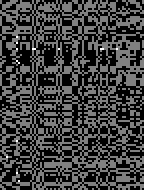

In [51]:
let 
    
    (number_of_metabolites, number_of_reactions) = size(S);
    B = zeros(number_of_metabolites, number_of_reactions); # initialize

    M = image_frames_dictionary[1];
    number_of_frames = 64;
    for i ∈ 2:number_of_frames
        M += image_frames_dictionary[i]
    end

    for i ∈ 1:number_of_metabolites
        for j ∈ 1:number_of_reactions
            if (M[i,j] < 0.0)
                B[i,j] = 0.0; # dark
            elseif (0.0 < M[i,j] < 2.0)
                B[i,j] = 0.5; # gray
            else
                B[i,j] = 1.0; # light
            end
        end
    end

    Gray.(transpose(B)) # rows are firms; columns are trading days
end

Next, let's interpret each of the SVD matrices in biochemical terms, starting with the `U::Array{Float64,2}` matrix. 

### $\mathbf{U}$: conservation relations

The columns of the $\mathbf{U}$ matrix form an orthonormal basis for metabolite space, where columns associated with zero singular values reveal conservation relations (weighted metabolite sums that remain constant over time).

> __Theorem: Conservation relations from SVD__
>
> Let $\mathbf{S} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^\top$ be the SVD of the stoichiometric matrix. Partition the columns of $\mathbf{U}$ as $\mathbf{U} = [\mathbf{U}_1 \; \mathbf{U}_0]$ where $\mathbf{U}_0$ contains columns corresponding to zero singular values. Then:
> $$\mathbf{S}^\top\mathbf{U}_0 = \mathbf{0}$$
> The columns of $\mathbf{U}_0$ form an orthonormal basis for all conservation relations. Any linear combination $\mathbf{w} = \mathbf{U}_0\mathbf{a}$ satisfies $\mathbf{S}^\top\mathbf{w} = \mathbf{0}$, meaning the weighted sum $\mathbf{w}^\top\mathbf{x}(t)$ is constant in time.

For the complete mathematical derivation, see the [companion derivation notebook](CHEME-151-M3-Derivation-U-STM-Watch-Studio.ipynb). Now let's extract and examine the conservation relations from our metabolic model. 

So which columns of `U::Array{Float64,2}` correspond to zero singular values? We'll store the indices of these columns in the `zero_sv_indices::Vector{Int}` variable.

In [14]:
zero_sv_indices = let

    # Tolerance for identifying zero singular values
    (m, n) = size(S);
    ϵ = eps(Float64);  # machine precision
    τ = ϵ * max(m, n) * Σ[1];  # tolerance threshold
    
    # Find indices of singular values below threshold (zero singular values)
    zero_sv_indices = findall(σ -> σ <= τ, Σ);
    
    zero_sv_indices; # return
end;

Next, we can extract the conservation relations matrix `U0::Array{Float64,2}` by selecting the appropriate columns from `U::Array{Float64,2}`.

In [15]:
U0 = U[:, zero_sv_indices] # extract the conservation relations matrix U0 by selecting columns of U corresponding to zero singular values

72×5 Matrix{Float64}:
 -4.76118e-17   2.28148e-17  -2.00488e-17   1.47381e-17  -1.53346e-17
 -7.67104e-17   1.79111e-16  -1.23574e-16   3.09238e-16  -7.94658e-17
 -2.33161e-16   1.87884e-16   3.84e-17      1.99718e-16  -1.05347e-16
 -9.25255e-17   4.58968e-17  -1.56225e-16   1.4342e-16    4.86025e-17
 -1.23506e-16  -9.25081e-17   1.81963e-17   1.87934e-17  -1.20875e-16
  3.61303e-16   5.04058e-17  -5.1489e-18    6.91954e-17  -5.32485e-17
  1.38719e-16  -1.60619e-16  -7.71439e-18  -8.81686e-17   3.01508e-18
  2.07247e-16  -1.79977e-16   1.28891e-16  -5.31869e-17  -1.55744e-16
 -6.4191e-17    8.2007e-17    2.74016e-17   5.27782e-17   3.70255e-17
 -9.05571e-17   5.10671e-17   7.80992e-17   4.54676e-17   5.93529e-17
  ⋮                                                      
 -2.26668e-16   3.02401e-16   4.66237e-17   2.68801e-16   5.23218e-17
 -1.18575e-16   3.21917e-16   3.19389e-16   4.67753e-16   3.18065e-17
 -2.46971e-16  -1.3525e-18   -2.62289e-16   8.51729e-17  -3.06664e-17
 -1.77931e

What do these conservation relations mean biologically? Each column of `U0::Array{Float64,2}` represents a conservation relation, which is a weighted sum of metabolites that remains constant over time. 

This implies that certain combinations of metabolites are conserved in the metabolic network, reflecting underlying biochemical constraints. Let's filter out the really small coefficients in the conservation relations for easier interpretation. We'll set a threshold value (e.g., `1e-3`) and zero out any coefficients in `U0::Array{Float64,2}` that are below this threshold in absolute value.

We'll save these filtered conservation relations in the `U0_filtered::Array{Float64,2}` variable.

In [16]:
U0_filtered = let

    threshold = 1e-6; # set threshold value
    U0_filtered = copy(U0); # make a copy of U0 to filter
    for i in eachindex(U0_filtered)
        if abs(U0_filtered[i]) < threshold
            U0_filtered[i] = 0.0; # zero out small coefficients
        end
    end
    U0_filtered; # return filtered conservation relations matrix
end

72×5 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 ⋮                   
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0

__Check__: If we multiply the transpose of the stoichiometric matrix $\mathbf{S}^{\top}$ by the conservation relations matrix `U0::Array{Float64,2}`, we should get a zero matrix. Let's verify this property to confirm that our extraction of conservation relations is correct.

In [17]:
let

    # initialize -
    ϵ = 1e-6; # threshold for considering a rhs as non-zero
    M = U0_filtered; # can be filtered or unfiltered U0
    rhs = transpose(S) * M; # compute the product Sᵀ * U0, set this to rhs

    # Are there any non-zero elements in rhs?
    @assert all(abs.(rhs) .< ϵ) "Error: There are non-zero elements in the product Sᵀ * U0, indicating an issue with the conservation relations extraction.";
end

Ok, so if we get here (and we didn't blow up), then our $\mathbf{U}_{0}$ array is correct! So let's look at these conservation relations. 

In [22]:
let

    # initialize -
    df = DataFrame();
    which_conservation_relation = 3; # choose which conservation relation to display

    # find the non-zero entries in the selected conservation relation
    conservation_relation = U0_filtered[:, which_conservation_relation] |> x -> findall(!=(0.0), x); # get indices of non-zero entries

    # create a chemical equation string representation of the conservation relation
    equation_terms = String[];
    for idx ∈ conservation_relation
        coeff = U0_filtered[idx, which_conservation_relation] |> x -> round(x, digits=3); # round coefficient for better readability
        metabolite_id = model["metabolites"][idx]["id"];
        metabolite_name = model["metabolites"][idx]["name"];
        
        # sometimes the formula field is missing, so we need to handle that
        formula = get(model["metabolites"][idx], "formula", "N/A");
        
        row_df = (
            Metabolite = metabolite_id,
            Name = metabolite_name,
            Formula = formula,
            Coefficient = coeff,
        );
        push!(df, row_df);
    end

    # let's make a pretty table
    pretty_table(
        df;
        backend = :text,
        alignment = [:l, :l, :l, :r],
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 ------------ ------------------------------------------------------- ---------------- -------------
  Metabolite   Name                                                    Formula          Coefficient 
  String       String                                                  String               Float64 
 ------------ ------------------------------------------------------- ---------------- -------------
  nad_c        Nicotinamide adenine dinucleotide                       C21H26N7O14P2         -0.025
  nadh_c       Nicotinamide adenine dinucleotide - reduced             C21H27N7O14P2         -0.025
  nadp_c       Nicotinamide adenine dinucleotide phosphate             C21H25N7O17P3         -0.119
  nadph_c      Nicotinamide adenine dinucleotide phosphate - reduced   C21H26N7O17P3         -0.119
  q8_c         Ubiquinone-8                                            C49H74O4               -0.23
  q8h2_c       Ubiquinol-8                                             C49H76O4               -0

___

### $\mathbf{V}$: steady-state flux patterns

The columns of $\mathbf{V}$ form an orthonormal basis for reaction space, where columns associated with zero singular values reveal steady-state flux patterns (flux distributions that produce no net metabolite accumulation).

> __Theorem: Steady-state flux patterns from SVD__
>
> Let $\mathbf{S} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^\top$ be the SVD of the stoichiometric matrix. Partition the columns of $\mathbf{V}$ as $\mathbf{V} = [\mathbf{V}_1 \; \mathbf{V}_0]$ where $\mathbf{V}_0$ contains columns corresponding to zero singular values. Then:
> $$\mathbf{S}\mathbf{V}_0 = \mathbf{0}$$
> The columns of $\mathbf{V}_0$ form an orthonormal basis for all steady-state flux patterns. Any linear combination $\mathbf{v} = \mathbf{V}_0\mathbf{a}$ satisfies $\mathbf{S}\mathbf{v} = \mathbf{0}$, representing balanced metabolic states with no net accumulation.

For the complete mathematical derivation, see [the companion derivation notebook](CHEME-151-M3-Derivation-V-STM-Watch-Studio.ipynb). These steady-state flux patterns represent the degrees of freedom in constraint-based metabolic modeling.

In [19]:
V0 = V[:, zero_sv_indices] # extract the conservation relations matrix U0 by selecting columns of U corresponding to zero singular values

95×5 Matrix{Float64}:
 -0.214782     0.128495     0.0345701    0.101179    0.197464
  0.131019     0.0433025    0.1168      -0.0371894   0.0119217
  0.197623    -0.0628385   -0.135636     0.0126537   0.00844214
  0.0461313   -0.0442445    0.0358139    0.0767262   0.0535509
 -0.0365003   -0.0833385    0.205455    -0.0577254   0.0180885
  0.0722272    0.132111    -0.154218     0.101374    0.170036
  0.173278    -0.029297     0.0863298   -0.0241414   0.176779
  0.050974    -0.0411645    0.0331128    0.0648979   0.0538117
  0.0119082    0.00757375  -0.00664194  -0.0290862   0.000641174
  0.135525     0.15552     -0.0144877   -0.180665    0.12707
  ⋮                                                 
  0.109503     0.226382     0.085571     0.118851   -0.10589
 -0.0371809    0.105783     0.0358117   -0.112605   -0.197299
 -0.00232523   0.0427347   -0.076963     0.203059    0.142066
  0.0124683   -0.0296182    0.0249179   -0.0849443   0.0659666
  0.0597246    0.110321    -0.174565    -0.086161

Fill me in later

In [20]:
let

    # initialize -
    ϵ = 1e-6; # threshold for considering a rhs as non-zero
    M = V0; # can be filtered or unfiltered V0
    rhs = S * M; # compute the product S * V0, set this to rhs

    # Are there any non-zero elements in rhs?
    @assert all(abs.(rhs) .< ϵ) "Error: There are non-zero elements in the product S * V0, indicating an issue with the conservation relations extraction.";
end

Fill me in later

In [30]:
let

    # initialize -
    df = DataFrame();
    which_conservation_relation = 1; # choose which conservation relation to display

    # find the non-zero entries in the selected conservation relation
    conservation_relation = V0[:, which_conservation_relation] |> x -> findall(y -> abs(y) > 0.01, x); # get indices of non-zero entries

    # create a chemical equation string representation of the conservation relation
    equation_terms = String[];
    for idx ∈ conservation_relation
        coeff = V0[idx, which_conservation_relation] |> x -> round(x, digits=3); # round coefficient for better readability
        reaction_id = model["reactions"][idx]["id"];
        reaction_name = model["reactions"][idx]["name"];
        
        row_df = (
            i = idx,
            Reaction = reaction_id,
            Coefficient = coeff,
        );
        push!(df, row_df);
    end

    # let's make a pretty table
    pretty_table(
        df;
        backend = :text,
        alignment = [:r, :l, :r],
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 ------- ------------- -------------
      i   Reaction      Coefficient 
  Int64   String            Float64 
 ------- ------------- -------------
      1   PFK                -0.215
      2   PFL                 0.131
      3   PGI                 0.198
      4   PGK                 0.046
      5   PGL                -0.037
      6   ACALD               0.072
      7   AKGt2r              0.173
      8   PGM                 0.051
      9   PIt2r               0.012
     10   ALCD2x              0.136
     11   ACALDt             -0.063
     12   ACKr               -0.053
     13   PPC                -0.096
     16   ATPM                  0.1
     17   PPCK               -0.142
     18   ACt2r              -0.053
     19   PPS                 0.172
     20   ADK1                0.172
     21   AKGDH               0.203
     22   ATPS4r              0.067
     23   PTAr                0.053
     24   PYK                 0.099
     26   PYRt2              -0.071
     28   RPE           

Fill me in later. What does this say?

___

## Summary
One concise summry sentence goes here.

> __Key Takeaways:__
>
> Three key takeaways go here.

One concise concluding sentence goes here.
___